# Robustness, Heterogeneity, Mechanisms, and Scalability

This notebook contains Phase III analyses. It tests diffusion and intervention behavior near the threshold, varies network size and structural parameters, changes seed placement, introduces heterogeneous sharing propensities, examines fragmentation mechanisms, and benchmarks ranking cost.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, kruskal, levene, ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
FIGURE_DIR = ROOT / 'figures'
OUTPUT_DIR = ROOT / 'analysis_outputs'
sys.path.insert(0, str(ROOT))
from misinformation_simulation import *
pd.set_option('display.max_columns', 60)
print('Project root:', ROOT)


Project root: /mnt/data/revision_work


In [2]:
rb=pd.read_csv(DATA_DIR/'robustness_baseline.csv')
ri=pd.read_csv(DATA_DIR/'robustness_intervention.csv')
he=pd.read_csv(DATA_DIR/'heterogeneity_results.csv')
sp=pd.read_csv(DATA_DIR/'seed_placement_results.csv')
ss=pd.read_csv(DATA_DIR/'structural_sensitivity.csv')
sc=pd.read_csv(DATA_DIR/'scalability_runtimes.csv')
[len(x) for x in [rb,ri,he,sp,ss,sc]]

[780, 1440, 1440, 240, 540, 84]

## Intervention rankings across transmission regimes

In [3]:
ri.groupby(['beta','topology','strategy'])[['final_size','reached_50','unique_exposed_fraction','attempted_exposures']].mean()

final_size  reached_50  \
beta topology strategy                                       
0.01 BA       betweenness              0.01460         0.0   
              collective_influence     0.01355         0.0   
              community_bridge         0.01430         0.0   
              degree                   0.01655         0.0   
              kcore                    0.01315         0.0   
...                                        ...         ...   
0.15 WS       collective_influence     0.94930         1.0   
              community_bridge         0.94845         1.0   
              degree                   0.94675         1.0   
              kcore                    0.94630         1.0   
              random                   0.94870         1.0   

                                    unique_exposed_fraction  \
beta topology strategy                                        
0.01 BA       betweenness                           0.05885   
              collective_influence                  0.04900   
              community_bridge                      0.05025   
              degree                                0.05850   
              kcore                                 0.04920   
...                                                     ...   
0.15 WS       collective_influence                  0.94500   
              community_bridge                      0.94475   
              degree                                0.94345   
              kcore                                 0.94315   
              random                                0.94490   

                                    attempted_exposures  
beta topology strategy                                   
0.01 BA       betweenness                        924.80  
              collective_influence               908.35  
              community_bridge                   923.60  
              degree                            1176.60  
              kcore                              765.15  
...                                                 ...  
0.15 WS       collective_influence              7002.10  
              community_bridge                  6916.25  
              degree                            7010.70  
              kcore                             7024.95  
              random                            7028.60  

[72 rows x 4 columns]

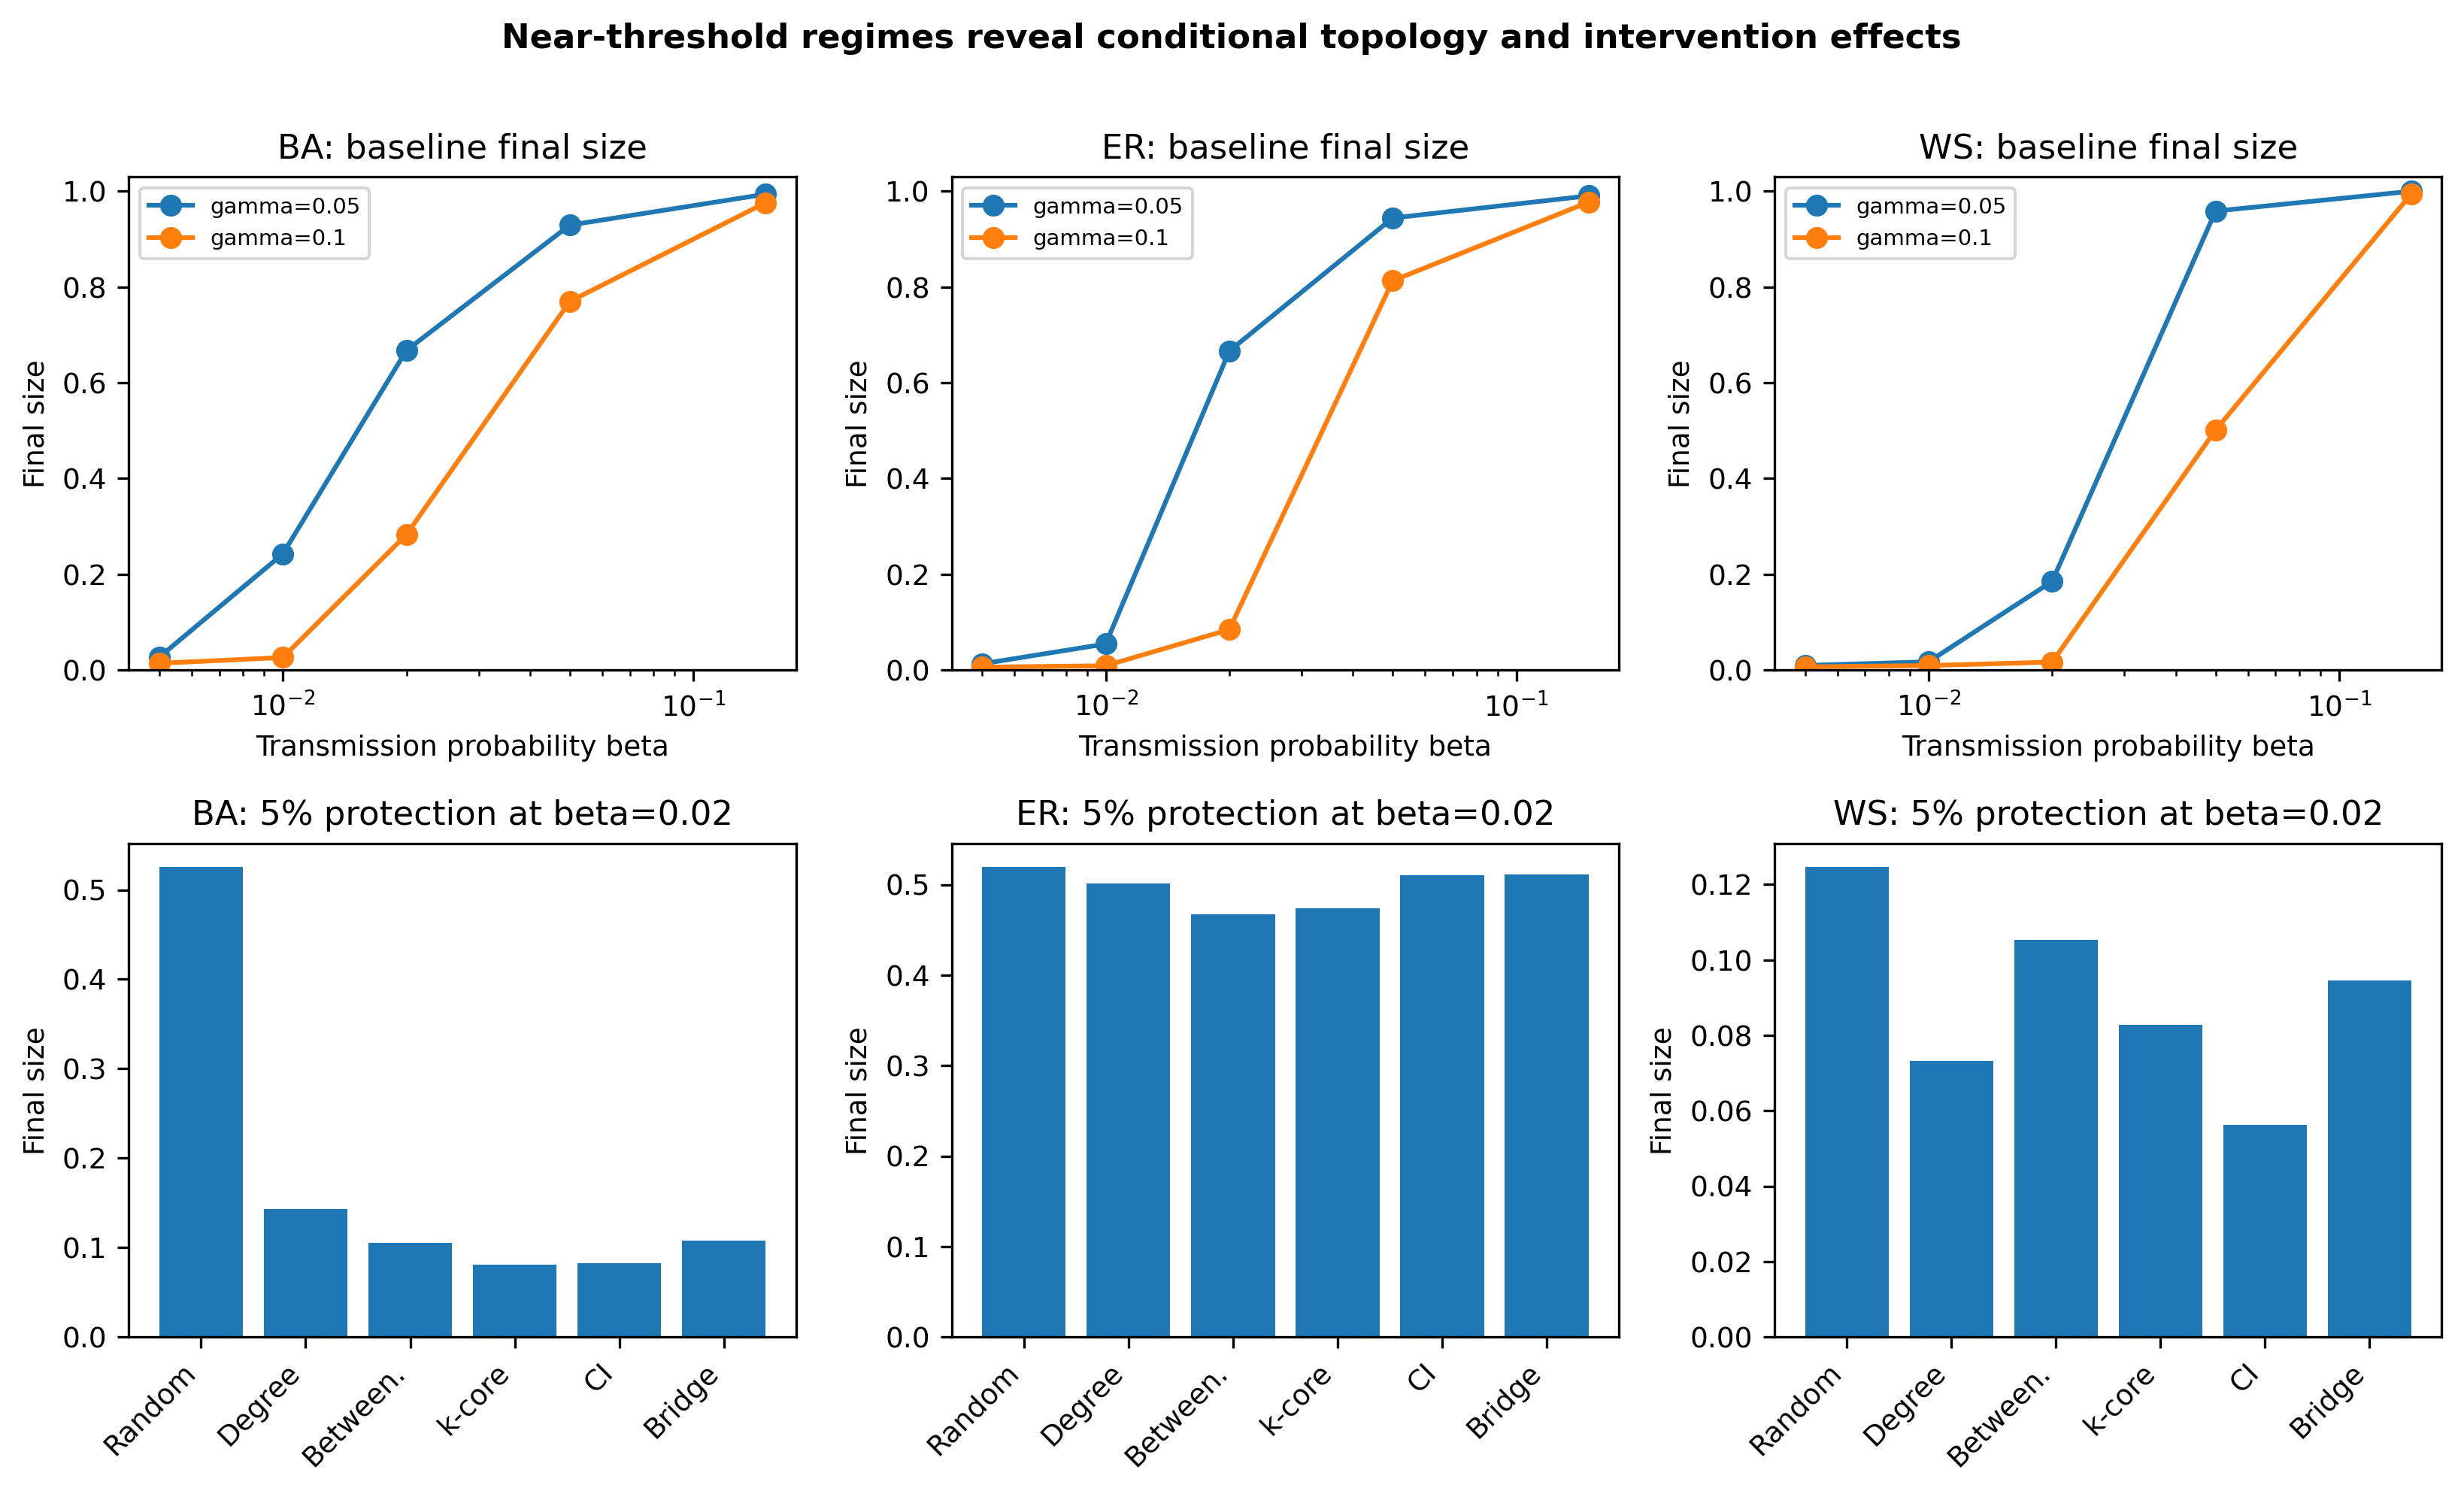

In [4]:
from IPython.display import Image, display
display(Image(filename=str(FIGURE_DIR/'figure_near_threshold.png')))

At beta = 0.02, five-percent targeted protection prevents all BA runs from reaching 50%, while 85% of random-protection BA runs reach that threshold. At beta = 0.15, all conditions are saturated enough to reach 50%, and the practical ranking differences are smaller.

## Heterogeneous behavior

In [5]:
he.groupby(['behavior','topology','strategy'])[['final_size','active_spreader_auc','unique_exposed_fraction']].mean()

final_size  \
behavior          topology strategy                           
degree_correlated BA       betweenness              0.82680   
                           collective_influence     0.82935   
                           community_bridge         0.82050   
                           degree                   0.80795   
                           kcore                    0.82310   
...                                                     ...   
strong            WS       collective_influence     0.94080   
                           community_bridge         0.93860   
                           degree                   0.93005   
                           kcore                    0.93140   
                           random                   0.94410   

                                                 active_spreader_auc  \
behavior          topology strategy                                    
degree_correlated BA       betweenness                      16488.90   
                           collective_influence             16696.00   
                           community_bridge                 16553.50   
                           degree                           16439.35   
                           kcore                            16556.55   
...                                                              ...   
strong            WS       collective_influence             18913.30   
                           community_bridge                 18456.55   
                           degree                           18537.30   
                           kcore                            18558.20   
                           random                           18836.15   

                                                 unique_exposed_fraction  
behavior          topology strategy                                       
degree_correlated BA       betweenness                           0.92435  
                           collective_influence                  0.92120  
                           community_bridge                      0.91740  
                           degree                                0.91415  
                           kcore                                 0.91800  
...                                                                  ...  
strong            WS       collective_influence                  0.94370  
                           community_bridge                      0.94265  
                           degree                                0.93820  
                           kcore                                 0.93825  
                           random                                0.94490  

[72 rows x 3 columns]

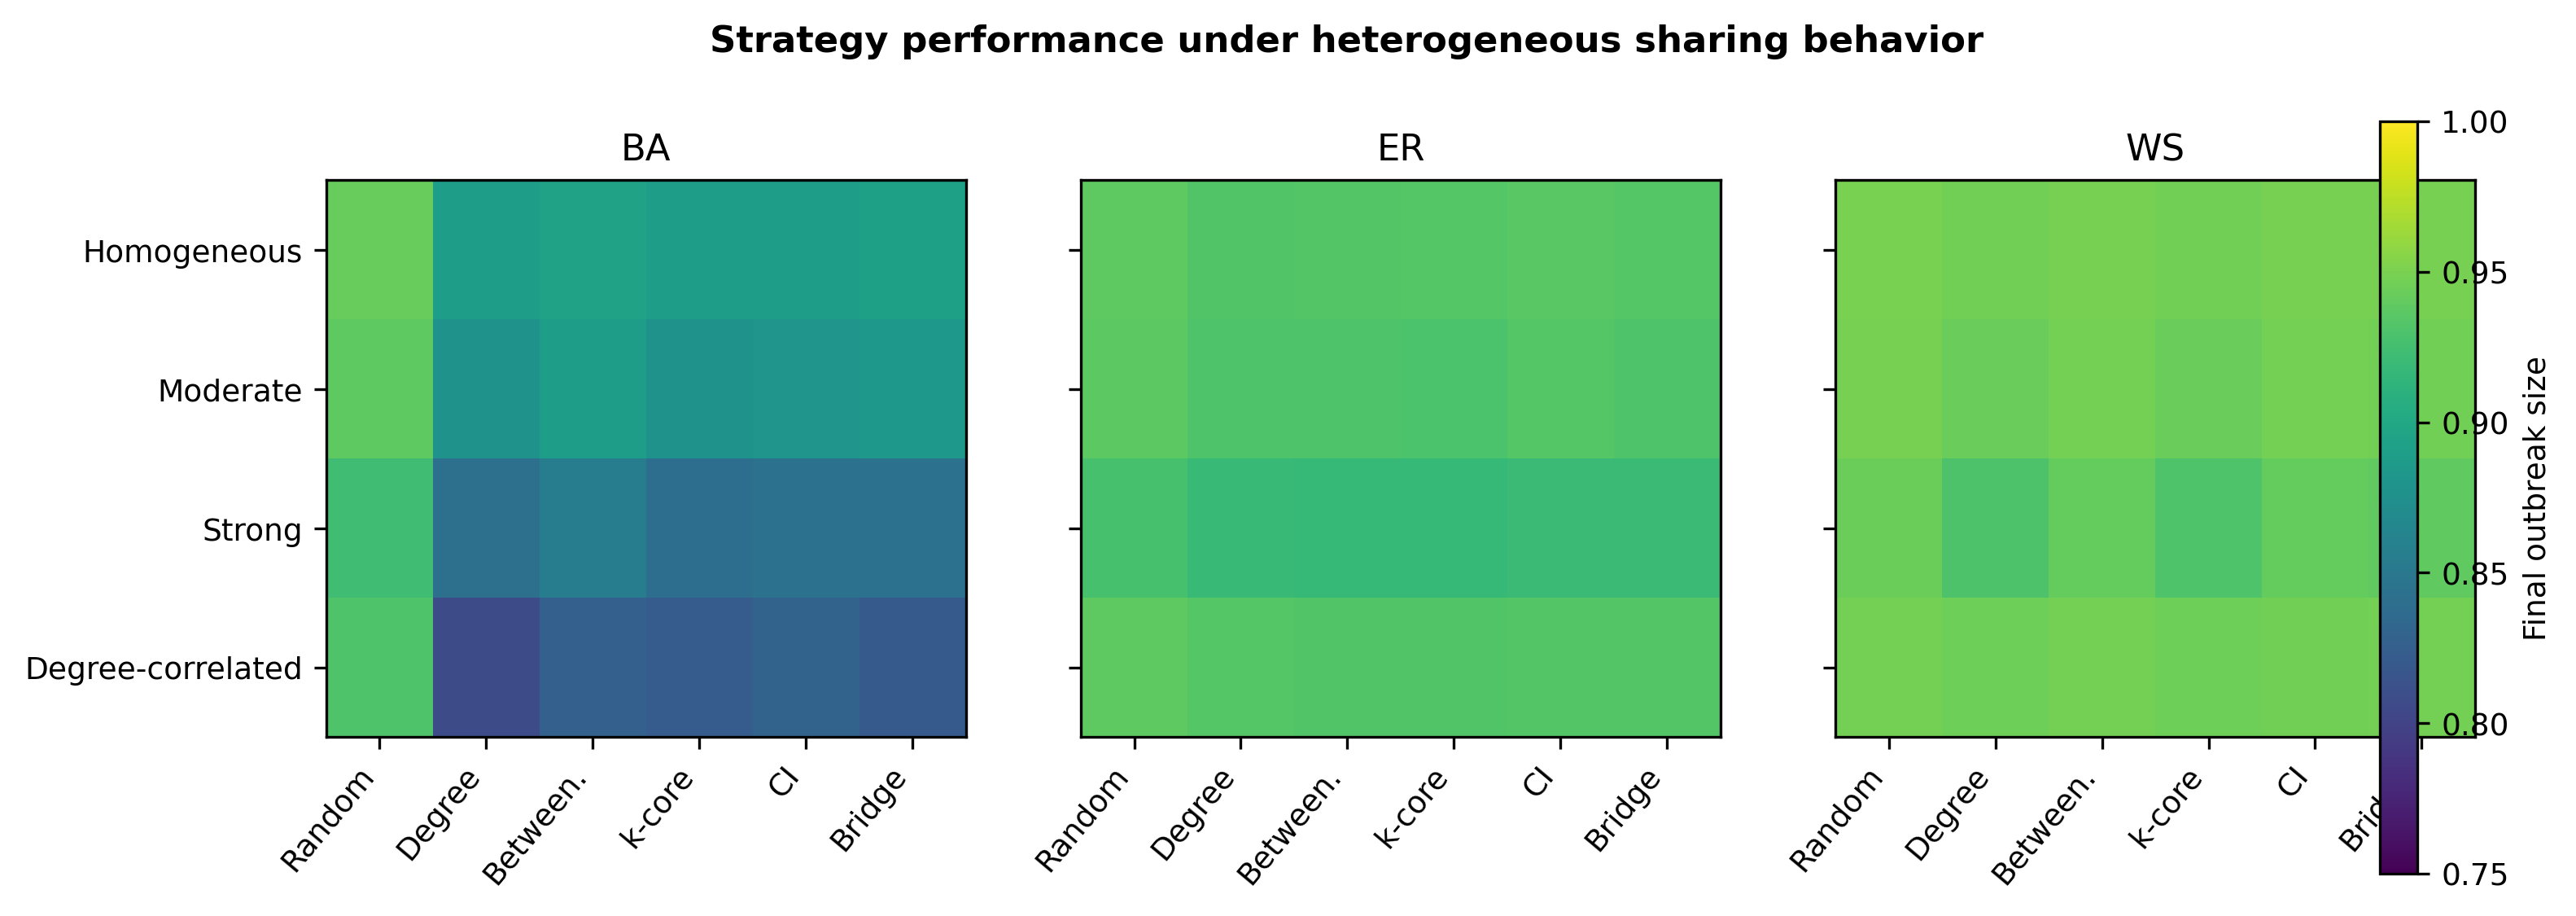

In [6]:
display(Image(filename=str(FIGURE_DIR/'figure_heterogeneity.png')))

Topology-aware strategies remain beneficial in BA networks under moderate, strong, and degree-correlated heterogeneity, but the exact winner changes. This supports a conditional rather than universal ranking claim.

## Structural sensitivity

In [7]:
ss.groupby(['family','value','topology'])[['mean_degree','clustering','lcc_fraction','t10','reached_50','final_size']].mean().head(60)

mean_degree  clustering  lcc_fraction    t10  \
family      value   topology                                                 
ba_m        2.00    BA            3.99200    0.026477       1.00000   5.90   
            3.00    BA            5.98200    0.029503       1.00000   4.55   
            5.00    BA            9.95000    0.040088       1.00000   3.40   
mean_degree 4.00    BA            3.99200    0.026000       1.00000   6.15   
                    ER            4.01180    0.003449       0.98015   8.75   
                    WS            4.00000    0.375409       1.00000  14.20   
            6.00    BA            5.98200    0.033552       1.00000   4.60   
                    ER            6.02760    0.005937       0.99830   5.90   
                    WS            6.00000    0.440972       1.00000   8.35   
            10.00   BA            9.95000    0.040582       1.00000   3.35   
                    ER            9.98960    0.010145       0.99995   4.10   
                    WS           10.00000    0.490701       1.00000   5.00   
n           500.00  BA            5.96400    0.052051       1.00000   4.10   
                    ER            5.98940    0.011607       0.99820   4.65   
                    WS            6.00000    0.443976       1.00000   5.85   
            1000.00 BA            5.98200    0.031344       1.00000   4.60   
                    ER            5.99400    0.005358       0.99740   5.95   
                    WS            6.00000    0.444969       1.00000   8.15   
            2000.00 BA            5.99100    0.017854       1.00000   5.45   
                    ER            6.01935    0.002878       0.99755   7.50   
                    WS            6.00000    0.443221       1.00000  10.70   
sbm_mixing  0.02    SBM           5.95940    0.022698       0.99770   5.95   
            0.10    SBM           6.00240    0.017580       0.99790   6.10   
            0.30    SBM           5.98300    0.009974       0.99810   6.40   
ws_rewire   0.01    WS            6.00000    0.583103       1.00000  10.65   
            0.10    WS            6.00000    0.444335       1.00000   8.30   
            0.50    WS            6.00000    0.078578       1.00000   6.45   

                              reached_50  final_size  
family      value   topology                          
ba_m        2.00    BA               1.0    0.967950  
            3.00    BA               1.0    0.995350  
            5.00    BA               1.0    0.999750  
mean_degree 4.00    BA               1.0    0.969500  
                    ER               1.0    0.950550  
                    WS               1.0    0.984550  
            6.00    BA               1.0    0.995500  
                    ER               1.0    0.990800  
                    WS               1.0    0.999550  
            10.00   BA               1.0    0.999800  
                    ER               1.0    0.999400  
                    WS               1.0    1.000000  
n           500.00  BA               1.0    0.993400  
                    ER               1.0    0.990900  
                    WS               1.0    0.999400  
            1000.00 BA               1.0    0.995100  
                    ER               1.0    0.990900  
                    WS               1.0    1.000000  
            2000.00 BA               1.0    0.995150  
                    ER               1.0    0.990300  
                    WS               1.0    0.999875  
sbm_mixing  0.02    SBM              1.0    0.989850  
            0.10    SBM              1.0    0.990800  
            0.30    SBM              1.0    0.990900  
ws_rewire   0.01    WS               1.0    0.998100  
            0.10    WS               1.0    0.999700  
            0.50    WS               1.0    0.999450

## Scalability

In [8]:
sc.groupby(['topology','n','strategy']).ranking_seconds.agg(['mean','std','median'])

mean       std    median
topology n    strategy                                          
BA       500  betweenness           0.113458  0.000267  0.113458
              collective_influence  0.010291  0.000102  0.010291
              community_bridge      0.162552  0.046038  0.162552
              degree                0.000712  0.000246  0.000712
              eigenvector           0.036378  0.000283  0.036378
              kcore                 0.001975  0.000071  0.001975
              pagerank              0.305030  0.001584  0.305030
         1000 betweenness           0.181855  0.000723  0.181855
              collective_influence  0.021495  0.001492  0.021495
              community_bridge      0.476910  0.026267  0.476910
              degree                0.001277  0.000189  0.001277
              eigenvector           0.033899  0.013587  0.033899
              kcore                 0.002936  0.000079  0.002936
              pagerank              0.252794  0.026649  0.252794
         2000 betweenness           0.359248  0.024411  0.359248
              collective_influence  0.052984  0.001266  0.052984
              community_bridge      1.397744  0.036802  1.397744
              degree                0.001796  0.000251  0.001796
              eigenvector           0.055170  0.000016  0.055170
              kcore                 0.005508  0.000129  0.005508
              pagerank              0.011037  0.000722  0.011037
WS       500  betweenness           0.084489  0.009793  0.084489
              collective_influence  0.003802  0.000189  0.003802
              community_bridge      0.081749  0.002843  0.081749
              degree                0.000409  0.000084  0.000409
              eigenvector           0.092363  0.015551  0.092363
              kcore                 0.001253  0.000018  0.001253
              pagerank              0.003218  0.000612  0.003218
         1000 betweenness           0.167680  0.007624  0.167680
              collective_influence  0.009863  0.003607  0.009863
              community_bridge      0.255203  0.010951  0.255203
              degree                0.000651  0.000080  0.000651
              eigenvector           0.267520  0.083045  0.267520
              kcore                 0.002788  0.000266  0.002788
              pagerank              0.006120  0.000980  0.006120
         2000 betweenness           0.351276  0.024019  0.351276
              collective_influence  0.015732  0.000797  0.015732
              community_bridge      0.766081  0.052514  0.766081
              degree                0.001656  0.000444  0.001656
              eigenvector           0.480937  0.071794  0.480937
              kcore                 0.004988  0.000280  0.004988
              pagerank              0.010862  0.001873  0.010862

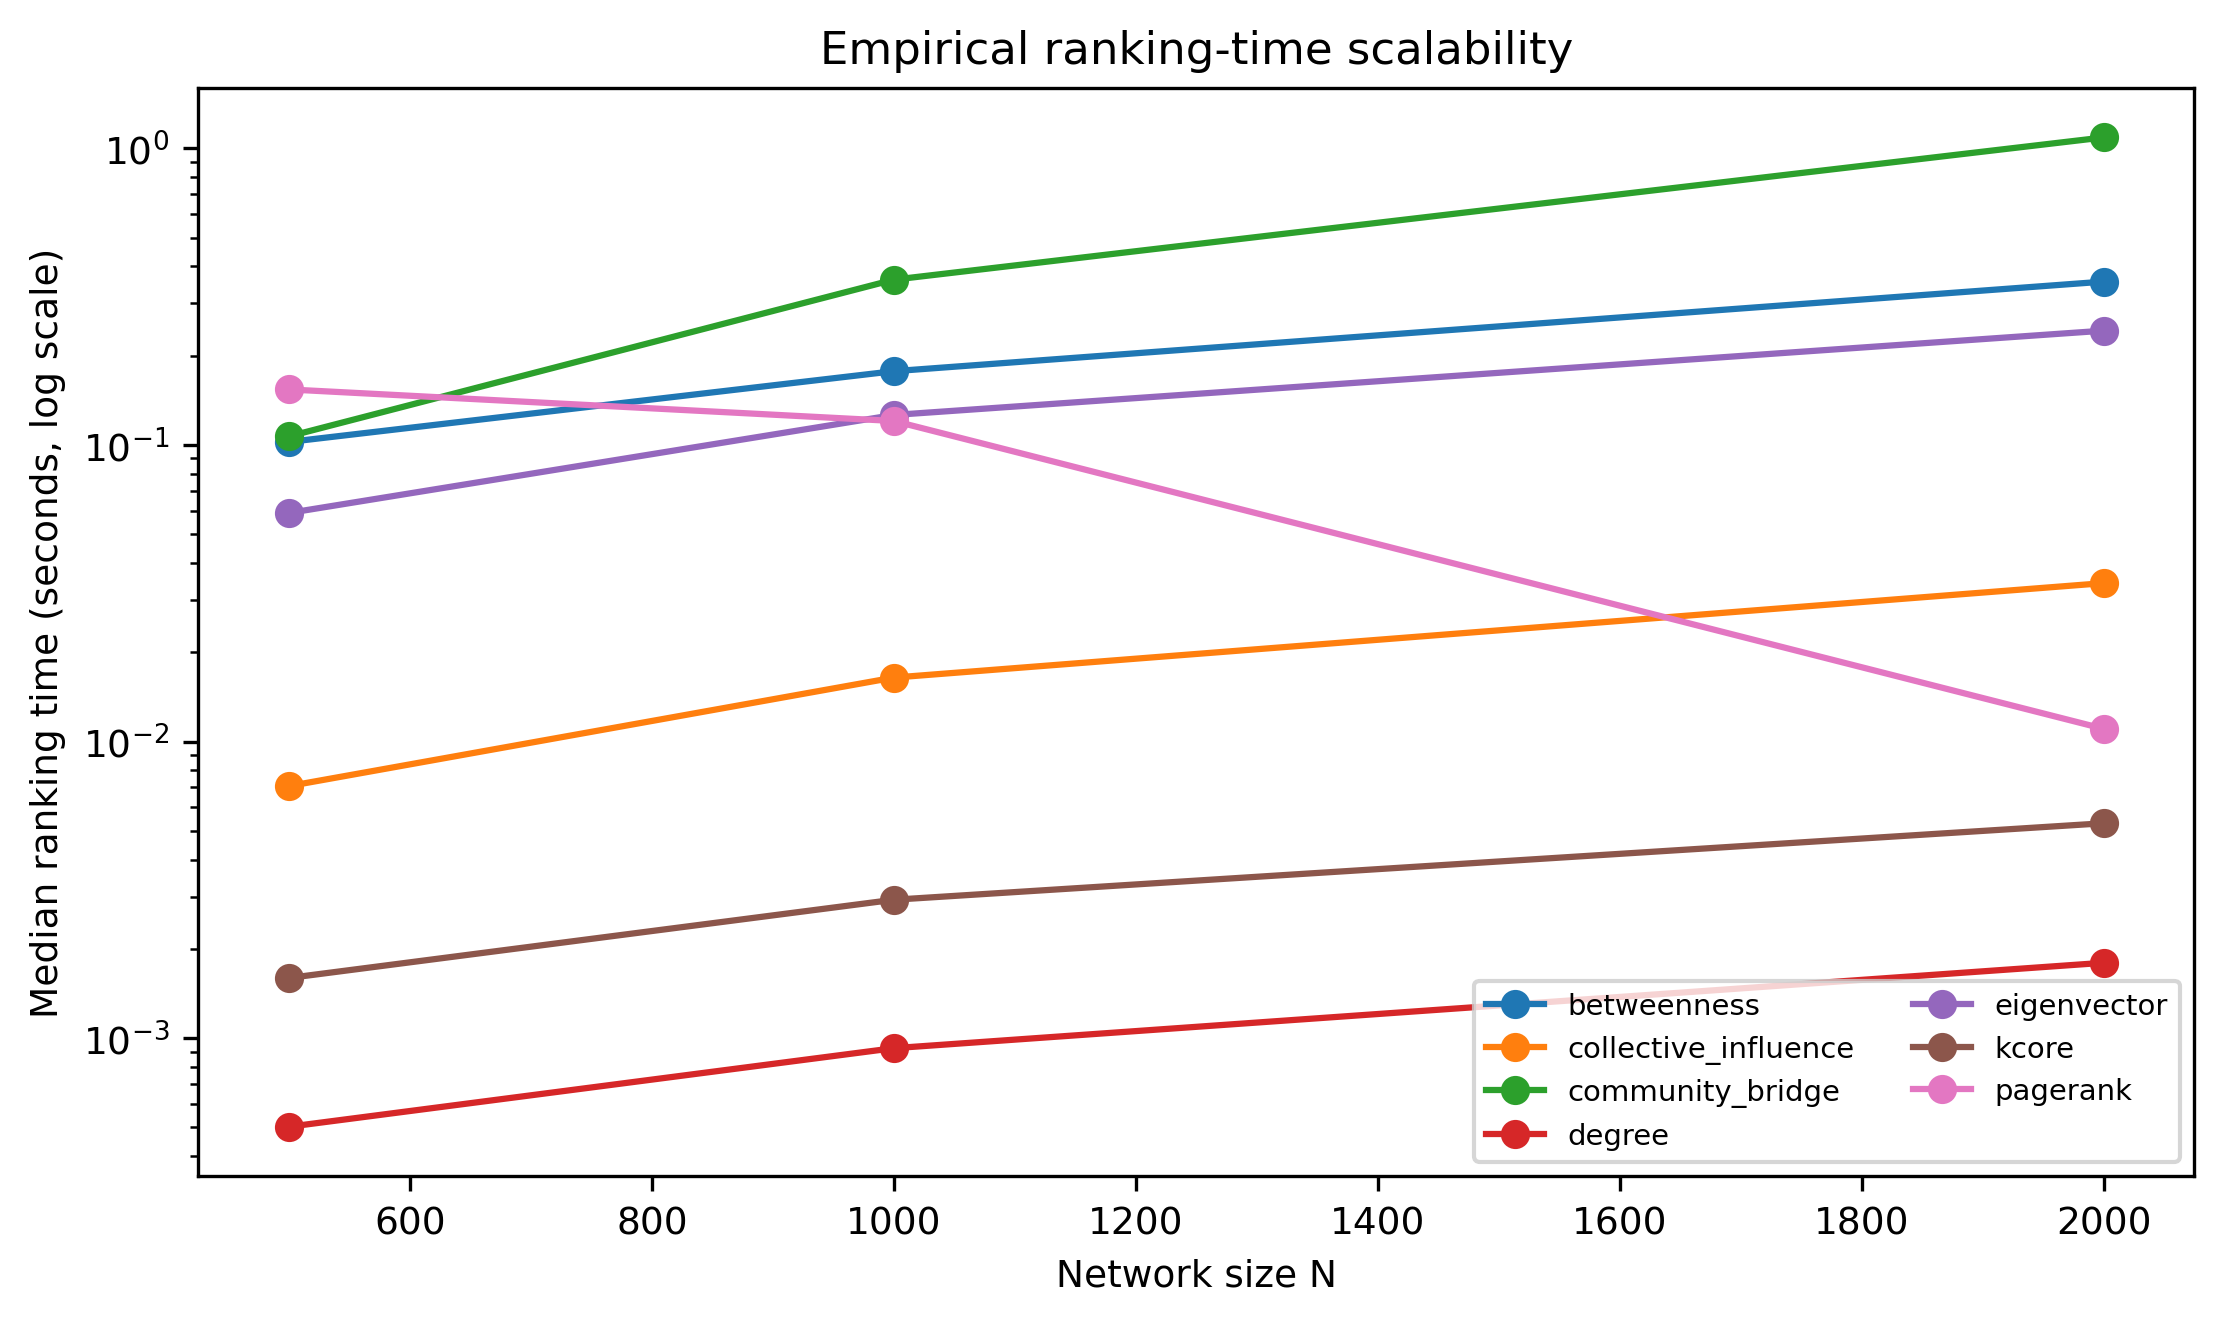

In [9]:
display(Image(filename=str(FIGURE_DIR/'figure_scalability.png')))

Degree and k-core rankings remain inexpensive. Approximate betweenness, eigenvector, and community-detection-based bridge rankings cost more and require more global information. The manuscript separately reports theoretical complexity and notes that exact betweenness is substantially more expensive than the sampled version benchmarked here.

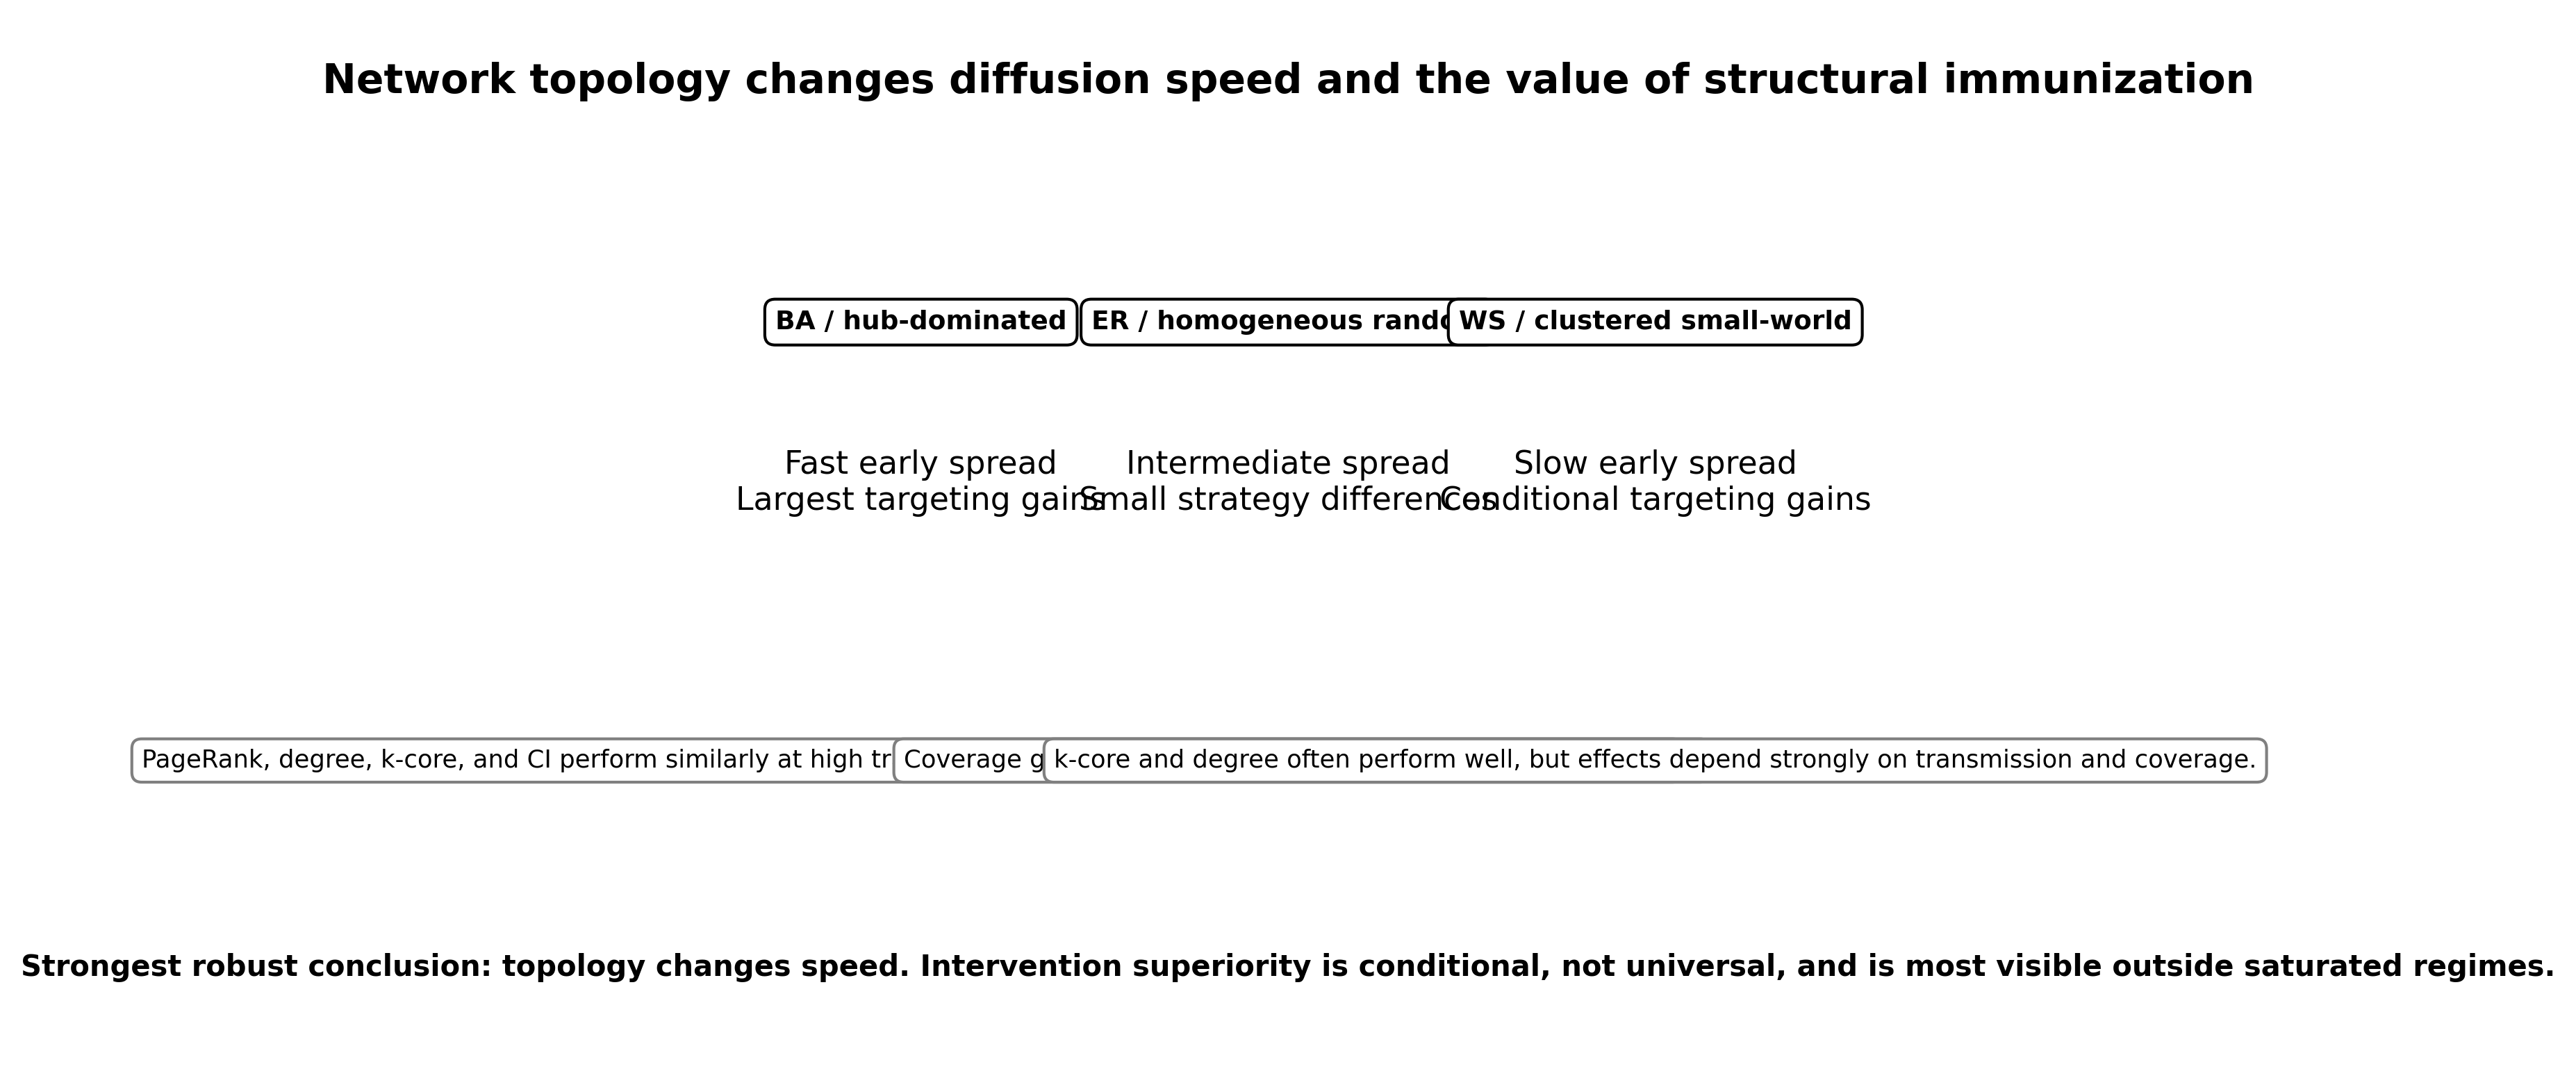

In [10]:
display(Image(filename=str(FIGURE_DIR/'figure_graphical_summary.png')))

## Files produced

The output CSVs preserve every simulation record and can be used to reproduce the manuscript tables. The full analysis intentionally keeps the primary 100-realization experiment separate from the 20-realization exploratory sensitivity families.